## Chapter 5. Decision Trees

의사결정 트리는 데이터를 일련의 조건에 따라 반복적으로 분할하면서 회귀부터 분류, 멀티출력 태스크도 수행할 수 있는 지도학습 알고리즘이다.
한 번에 하나의 피쳐만 보고 임계값과 비교하기 때문에, 표준화(zscoring)가 전혀 필요하지 않는 것이 특징이다.

In [1]:
# 의사결정 트리 학습

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

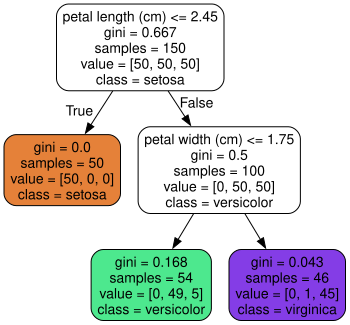

In [2]:
# 의사결정 트리 시각화

from sklearn.tree import export_graphviz
from graphviz import Source
import os

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

export_graphviz(
	tree_clf,
	out_file="iris_tree.dot",
	feature_names=["petal length (cm)", "petal width (cm)"],
	class_names=iris.target_names,
	rounded=True,
	filled=True
)

Source.from_file("iris_tree.dot")

# samples는 노드에 해당하는 인스턴스의 개수를 의미한다.
# value는 노드에 해당하는 각 클래스별 인스턴스의 개수를 의미한다.
# gini는 Gini impurity를 의미한다. 0일 때, 순수함을 뜻하고, 노드의 모든 훈련 인스턴스가 동일한 클래스에 속할 때, 순수하다.

#### 지니 불순도(Gini impurity)

클래스가 많을수록 그리고 혼합될수록 불순도가 커진다.

- G_i = 1 - sum((p_i,k)^2)

#### 모델 해석: 화이트 박스 vs 블랙 박스

직관적이고 결정값을 해석하기 쉬운 의사 결정 트리같은 모델을 화이트 박스라고 부른다.
반면, 예측이 이루어진 이유를 간단하게 설명하기 어려운 
랜덤 포레스트와 신경망은 일반적으로 블랙 박스라고 부른다.

#### 클래스 확률 추정

특정 클래스 k에 속할 확률을 추정하여  가장 높은 확률로 추정한 클래스를 찾을 수도 있다.

In [3]:
# 클래스 확률 추정

print(tree_clf.predict_proba([[5, 1.5]]).round(3)) # 꽃잎 길이 5cm, 너비 1.5cm의 클래스 확률 추정
print(tree_clf.predict([[5, 1.5]])) # 가장 높은 확률로 추정한 클래스로 예측값 출력

[[0.    0.907 0.093]]
[1]


#### CART 학습 알고리즘

Scikit-Learn은 의사결정 트리를 CART(Classification and Regression Tree) 알고리즘을 통해 학습시킨다. 먼저 단일 피쳐 k와 임계값 tk을 사용하여 훈련 데이터셋을 두 개로 분할한다. 가장 순수한 부분 집합을 생성하는 k, tk쌍을 찾는다. 이 때 비용함수의 최저점을 그리디하게 탐색하여 찾는다. 이런 그리디한 특성 때문에 사실상 로컬 최적해를 찾게되고, 글로벌 최적해를 찾긴 매우 어렵다.

#### 계산 복잡도

만약 진짜 글로벌 최적해를 찾는다면 시간 복잡도는 훈련 인스턴스 m에 대해 
**O(exp(m))**로 최악 수준이다.

- 예측 복잡도: 트리가 균형이라면, 루트에서 리프까지의 깊이는 log2​m 정도로 예측 복잡도는 **O(log2​m)** 수준이다.
- 훈련 복잡도: 각 노드마다 최선의 분할을 찾기 위해 모든 n개 피쳐를 그 노드에 도달한 모든 샘플에 대해 비교하므로 복잡도는 예측과 달리 n에 비례한다. **O(n×mlog2​m)**
- 훈련 속도 개선: max_depth를 제한해서 트리를 얕게하면, 훈련 자체의 횟수가 줄고, 무작위 피쳐 샘플링을 통해 노드당 비교 대상이 n보다 줄어들어 훈련 속도를 개선할 수 있다.
다만, 이에 대해서는 편향이 증가하여 과소적합 리스크가 발생하는 편향-분산 트레이드오프가 존재한다.

#### 불순도 측정 방법: 지니 불순도, 엔트로피

사이킷런의 DecisionTreeClassfier 클래스의 cirterion 하이퍼파라미터의 default는 "gini"이고, "entropy"로 바꿀 수 있다. 트리 모양에 대해서 둘의 차이는 대부분의 경우에서 미미하다.

- 지니 불순도: 계산 복잡도가 낮고, 최빈 클래스를 독립 가지로 분리하는 경향이 있다.
- 엔트로피: 계산 복잡도가 비교적 약간 높고, 좀 더 균형 잡힌 트리 결과를 보인다.

#### 규제(Regularization) 하이퍼파라미터 - 과적합 방지

비모수 모델인 의사결정 트리는 모수 모델인 선형 모델과 달리 훈련 데이터에 대해 어떤 함수적 형태를 따른다는 가정을 거의 하지 않는다.

##### 규제 하이퍼파라미터들
- max_* 감소: 트리가 커질 수 있는 상한을 낮춤
- min_* 증가: 분할, 리프 생성에 필요한 최소 조건을 높임
- ccp_alpha 증가: 사후 가지치기 강도를 높임

##### 사전 가지치기 vs 사후 가지치기
- 사전 가지치기: 트리를 키우면서 애초에 일정 높이 이상 자라지 못하게 사전에 제한
- 사후 가지치기: 일단 트리를 최대한 다 키운 다음, 쓸모없는 가지를 쳐냄

In [ ]:
# Moons 데이터셋 실험

from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42) # 규제 없이
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42) # 규제 하이퍼파라미터 적용
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
# 규제 없는 모델은 과적합되었음을 확인, 규제 모델이 뚜렷하게 더 높은 정확도를 보임

X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2, random_state=42)

print(tree_clf1.score(X_moons_test, y_moons_test))
print(tree_clf2.score(X_moons_test, y_moons_test))

0.901
0.918


#### 회귀

의사결정 트리는 회귀 분석에 대해서도 작업을 수행할 수 있다. 선형 데이터뿐만 아니라, 다양하 복잡한 데이터 셋에 적용할 수 있다. 트리의 각 노드는 클래스를 예측하는 분류와 달리, 연속적인 숫자 값을 예측한다.

In [ ]:
# 회귀 의사결정 트리

import numpy as np
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(seed=42)
X_quad = rng.random((200, 1)) - 0.5
y_quad = X_quad ** 2 + 0.025 * rng.standard_normal((200, 1)) # y = X^2 형태로 비선형 관계
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

# 리프 노드 안에 각 값들이 대표값과 최대한 벗어나지 않도록 동질적으로 모으는 것이 핵심 목표다.

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

#### 축 방향 민감성

##### 트리의 한계: 직교 결정경계
결정경계가 항상 어떤 축에 대해 수직이다. 즉 대각선 경계는 한 번에 그릴 수 없다. 따라서 대각선을 흉내내기 위해 수많은 계단식 분할을 복잡하게 진행하게 되고, 이는 과적합으로 이어지기 쉽다. 트리가 데이터의 방향에 민감한 것이 특징이다.

##### 해결책: 스케일링, PCA(주성분분석)로 데이터 회전
PCA는 피쳐 간 상관관계가 줄어들도록 데이터를 회전시키는 기법이다.
원래는 대각선인 데이터 패턴을 회전을 통해 축에 맞춘다. 항상 해결되지는 않지만, 데이터 구조에 따라 도움이 될 때가 많다.

In [8]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)
tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

#### 트리의 근본적인 문제: 높은 분산

훈련 조건을 조금만 바꿔도, 최종적으로 만들어지는 모델은 완전히 바뀔 수 있다.
CART 알고리즘의 확률적 요소 때문에 시드를 고정하지 않는다면, 심지어 같은 데이터로 재훈련해도 다른 트리가 나올 수 있다.

#### Exercises

1. 백만 개의 인스턴스로 구성된 훈련 데이터셋을 사용하여 제한 없이 훈련된 의사결정 트리의 대략적인 깊이는?
-> log(1_000_000) (밑 2인 log)

2. 노드의 지니 불순도는 일반적으로 그것의 부모보다 높은가 낮은가? 일반적으로 그런 것 인가 항상 그런가?
-> 항상 그런 것은 아니지만, 일반적으로 부모보다 낮은 지니 불순도를 가진다.

3. 결정 트리가 훈련 셋에 과적합되었다면, max_depth를 줄여보는 것은 좋은 생각인가?
-> 맞다. max_depth를 줄여서 트리의 복잡도를 낮추는 시도를 통해 과적합을 억제해볼 수 있다.

4. 결정 트리가 훈련 셋에 과소적합되었다면, 입력 피쳐를 스케일링 시도하는 것은 좋은 생각인가?
-> 아니다. 별로 도움이 안 된다. 결정 트리는 피쳐 스케일링에 영향을 받는 알고리즘이 아니기 때문이다.
모델의 복잡도를 늘리는 방향으로 해결해야 한다.

5. 백만 개의 인스턴스가 포함된 훈련 셋으로 결정 트리를 학습하는 데 한 시간이 걸린다면,
천만 개의 인스턴스가 포함된 훈련 셋으로 또 다른 결정 트리를 학습하는 데는 대략 얼마나 걸릴까?
-> O(n×mlog(m)), mlog(m) 부분을 보면, 인스턴스 수가 10배 늘어남에 따라 시간은 10배 보다 조금 더 걸린다는 것을 알 수 있다.
대략적으로 약 12시간 정도 걸릴 것 이다.

6. 주어진 학습 데이터셋으로 결정 트리를 학습시키는 데 한 시간이 걸린다면, 특성 개수를 두배로 늘리면 대략 얼마나 걸릴까?
-> O(n×mlog(m)), n이 두 배로 늘어나므로, 대략 두 시간 정도 걸릴 것 이다.

In [ ]:
# Exercises 7. moons 데이터셋 결정 트리 학습시키고 미세 조정하기.

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 데이터 준비
X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(X_moons, y_moons,
																			test_size=0.2, random_state=42)

tree_clf = DecisionTreeClassifier(random_state=42)
# 하이퍼파라미터(max_leaf_nodes) 탐색 범위
param_grid = {
	"max_leaf_nodes": np.arange(2, 100)
}
# 그리드서치
grid_search = GridSearchCV(estimator=tree_clf, param_grid=param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_moons_train, y_moons_train)

best_model = grid_search.best_estimator_ # 최적 하이퍼파라미터 적용

accuracy = best_model.score(X_moons_test, y_moons_test)
print(accuracy) # 정확도 약 87%

0.8666666666666667


In [63]:
# Exercises 8. 랜덤 포레스트 구현하기

from sklearn.model_selection import ShuffleSplit
from scipy.stats import mode
from sklearn.base import clone
from sklearn.metrics import accuracy_score

mini_batches = []

rs = ShuffleSplit(n_splits=1000, train_size=100, random_state=42)
# rs.split()은 (train_idx, test_idx) 형태를 반환한다.
for train_idx, _ in rs.split(X_moons_train):
	X_mini_train = X_moons_train[train_idx]
	y_mini_train = y_moons_train[train_idx]
	mini_batches.append((X_mini_train, y_mini_train))

# 1000개 트리 생성 및 학습
forest = [clone(best_model) for _ in range(1000)]
# 개별 점수를 담을 리스트
acc_list = []
# 개별 트리 미니 배치 학습
for tree, (X_mini_train, y_mini_train) in zip(forest, mini_batches):
	tree.fit(X_mini_train, y_mini_train)

	acc_list.append(tree.score(X_moons_test, y_moons_test))
# 개별 트리 정확도의 평균
print(np.mean(acc_list))

Y_pred = np.empty((1000, len(X_moons_test)), dtype=np.int64)

for tree_idx, tree in enumerate(forest):
	Y_pred[tree_idx] = tree.predict(X_moons_test)
# mode로 최빈값 계산
y_pred_majority_votes, _ = mode(Y_pred, axis=0)

ensemble_acc = accuracy_score(y_moons_test, y_pred_majority_votes.ravel())
print(ensemble_acc)

0.8569666666666669
0.8666666666666667


## Chapter 6. Ensemble Learning and Random Forests

앙상블이란 복잡한 문제를 해결하기 위해 전문가 한 명에게 묻는 것보다, 수천 명의 평범한 사람들에게 물어 답을 집계하는 것이 오히려 더 정확하다는 직관에서 출발한다.

각 개체의 오차들이 **서로 독립적**이라면, 그 답을 많이 모을수록 오차들이 서로 상쇄되어 집계된 답이 정답에 가까워진다.

여러 개의 예측 모델을 결합하여 하나의 단일 모델보다 더 높은 성능과 안정성을 갖는 최적의 예측 모델을 만드는 기법이다.

보통 이미 괜찮은 개별 모델 몇 개를 만들어 둔 상태에서 그것들을 조합해 성능을 한 단계 더 끌어올리는 용도로 쓴다.

#### 보팅 분류기

하드 보팅: 가장 많은 표를 얻은 클래스가 앙상블의 예측이 되는 다수결 방식

소프트 보팅: 모든 개별 분류기의 확률을 평균하여 가장 높은 클래스 확률을 가진 클래스를 예측하는 방식
확신도가 높은 투표에 더 많은 가중치를 부여하기 때문에 하드 방식보다 더 나은 성능을 보이는 경우가 많다.
추정 확률이 잘 보정되었을 때 가장 효과적이다.

In [9]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 독립성 확보를 위해 서로 다른 세 가지 분류기로 구성된 투표 분류기
voting_clf = VotingClassifier(
	estimators=[
		('lr', LogisticRegression(random_state=42)),
		('rf', RandomForestClassifier(random_state=42)),
		('svc', SVC(random_state=42))
	]
)
voting_clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [ ]:
# 각 개별 분류기에 대한 성능 확인

for name, clf in voting_clf.named_estimators_.items():
	print(name, '=', clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


In [ ]:
print(voting_clf.predict(X_test[:1])) # predict() 메서드는 하드 보팅 수행
print([clf.predict(X_test[:1]) for clf in voting_clf.estimators_])

# 보팅 분류기의 성능 확인
print(voting_clf.score(X_test, y_test)) # 개별 분류기보다 높은 정확도를 보여줌

[1]
[array([1]), array([1]), array([0])]
0.912


In [15]:
# 소프트 보팅

voting_clf.voting = "soft"
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train, y_train)
print(voting_clf.score(X_test, y_test))

0.92


#### 배깅/페이스팅

보팅은 서로 다른 알고리즘들을 같은 훈련 세트로 학습하는 반면, 배깅/페이스팅은 같은 알고리즘을 서로 다른 훈련 서브셋으로 학습한다.
분류에서는 최빈값(다수결), 회귀에서는 평균으로 집계한다.

학습 시,
- 배깅: 복원추출 (중복 가능), 노이즈 많은 데이터나 과적합 잘 되는 모델에 유리, 복원추출 때문에 서브셋 간 다양성이 더 크다. -> 분산 감소 효과 더 큼
- 페이스팅: 비복원추출, 계산 효율이 비교적 조금 더 좋음

예측기가 서로 독립적이라면, 앙상블을 통해 분산이 줄어 과적합을 어느정도 억제할 수 있다.

In [18]:
# 배깅

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(),
							n_estimators=500, max_samples=100, oob_score=True,
							n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)

# base estimator가 predict_proba()를 지원하면, 집계의 최빈값(다수결) 하드보팅 방식이 평균 소프트보팅 방식으로 자동 전환된다.

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",100
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


#### Out-of-Bag 평가

복원추출 방식인 배깅을 통해 학습하면 보통 하나의 예측기 입장에서 한 번도 보지 못한 데이터가 나온다.
그것이 OOB 인스턴스이다. 이 OOB 자체가 검증셋 역할을 할 수 있다.

반면, 비복원추출 방식인 페이스팅은 max_samples라는 파라미터를 조정을 통해 한 번도 보지 못한 데이터가 생길 수는 있으나, 알고리즘 자체가 그것을 보장하지 않기 때문에 OOB 개념이 없다.

In [ ]:
from sklearn.metrics import accuracy_score

print(bag_clf.oob_score_) # oob score

y_pred = bag_clf.predict(X_test)
print(accuracy_score(y_test, y_pred))

print(bag_clf.oob_decision_function_[:3]) # 첫 세 개의 인스턴스에 대한 확률 추정값

0.9253333333333333
0.904
[[0.35579515 0.64420485]
 [0.43513514 0.56486486]
 [1.         0.        ]]


#### 특성 샘플링

배깅/페이스팅 로직이 인스턴스 뿐만 아니라, 특성에도 똑같이 적용 가능하다.
차원이 매우 높은 입력을 다룰 때, 모든 특성을 학습하면 시간이 너무 오래 걸려서 특성 샘플링을 통해
시간은 줄일 수 있다. 특성 샘플링을 통해 더 큰 다양성을 가져갈 수 있다.

#### 랜덤 포레스트

배깅으로 결정트리들을 앙상블한 것이다. 트리 하나 안에서도 **노드마다** 매번 다시 무작위로 특성을 뽑아서, 그 중에서 최선의 분할을 찾는다. 트리 간 상관관계를 최대한 낮춰서, 배깅 단독보다 더 강한 분산 감소 효과가 있다.

In [ ]:
# 랜덤 포레스트

from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
								 n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)

y_pred_rf = rnd_clf.predict(X_test)

In [24]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(max_features="sqrt",
												   max_leaf_nodes=16),
												   n_estimators=500, n_jobs=-1, random_state=42)

#### Extra-Trees

랜덤 포레스트에서 무작위성을 더 끌어올린 것이다. 노드를 분할할 때 먼저 전체 특성 중 랜덤 서브셋을 고르고(랜덤 포레스트와 동일)
그 서브셋 안에서 어떤 특성을 쓸지와 그 특성의 임계값을 어디로 할지를 최선을 탐색하지 않고 무작위로 정한다.

#### 특성 중요도

불순도 감소량을 기준으로 중요도를 따진다. 어떤 특성을 써서 분할했을 때 불순도가 많이 줄었다면,
그 특성이 중요한 것이라고 본다. 불순도 감소량은 샘플 수가 많은 노드일수록 더 가중치를 줘서 평균한다.

이런 특성 중요도를 활용해 특성 선택에 사용한다.

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)
# 특성 중요도 출력
for score, name in zip(rnd_clf.feature_importances_,
					   iris.data.columns):
	print(round(score, 2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


#### 부스팅

지금까지는 예측기들을 서로 독립적(병렬)으로 학습시켰다. 부스팅은 예측기들이 순자척으로 학습되고, 각 예측기가 바로 앞 예측기의 실수를 고치는 방향으로 학습된다. 모델 하나하나가 약하더라도, 여러 개를 순차적으로 이어붙여서 서로의 약점을 보완하면 결과적으로 강한 학습기가 될 수 있다. 약한 학습기 하나하나가 가진 높은 편향을 순차적으로 줄여나간다.

#### AdaBoost

틀린 문제에 가중치를 매겨서 다음 학생한테 넘기는 구조다. 
1) 먼저 처음에는 모든 훈련 인스턴스의 가중치를 동일하게 시작한다.
2) 예측기가 학습하고 예측하면서 가중치를 반영하여 틀린 정도(가중 오차율)를 계산한다.
3) 그 예측기 자체의 가중치(신뢰도, α)를 계산한다.
4) 틀린 인스턴스에 대한 가중치를 키우고, 전체 가중치 합이 다시 1이되도록 정규화해서 인스턴스의 가중치를 업데이트한다.
5) 원하는 예측기 개수에 도달하거나, 완벽한 예측기가 나올 때 까지 이 과정을 반복한다.

예측기의 신뢰도로 가중치를 준 투표(정확도가 더 높았던 예측치의 표가 더 무겁게 반영)를 통해 최종 예측을 진행한다.

매 단계마다 이전 단계의 결과를 보고 다음 스텝을 조금씩 개선해나간다는 점에서 경사하강법과 유사하다.
병렬화가 안되는 것이 구조적 특징이고, 예측기를 너무 많이 이어붙이면 과적합 리스크가 있을 수 있다.

In [ ]:
# AdaBoostClassifier

from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
	DecisionTreeClassifier(max_depth=1), n_estimators=30, learning_rate=0.5,
	random_state=42, algorithm="SAMME"
)
ada_clf.fit(X_train, y_train)

#### 그래디언트 부스팅

잔차에 새 모델을 직접 학습한다. 이전 모델이 못 맞춘 차이 그 자체를 새 타겟으로 삼는다.
잔차를 직접 다음 모델의 학습 목표로 삼아 순차적으로 누적 보정해나가므로 최종 예측은 모든 트리 예측의 합이된다.

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

m = 100 # 인스턴스 수
rng = np.random.default_rng(seed=42)
X = rng.random((m, 1)) - 0.5
noise = 0.05 * rng.standard_normal(m)

y = 3 * X[:, 0] ** 2 + noise # y = 3x² + Gaussian noise

tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

y2 = y - tree_reg1.predict(X) # 1번 트리의 잔차
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X, y2)

y3 = y2 - tree_reg2.predict(X) # 2번 트리의 잔차
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X, y3)

X_new = np.array([[-0.4], [0.], [0.5]])
print(sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))) # 모두 더하기

[0.57356534 0.0405142  0.66914249]


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3,
								 learning_rate=1.0, random_state=42)
gbrt.fit(X, y)
# 더 낮은 학습률, 더 큰 트리 개수 상한, 조기 종료 추가
gbrt_best = GradientBoostingRegressor(max_depth=2, learning_rate=0.05,
									  n_estimators=500, n_iter_no_change=10,
									  random_state=42)

gbrt_best.fit(X, y)

print(gbrt_best.n_estimators_)

53


#### 히스토그램 기반 그래디언트 부스팅(HGB)

연속값 특성을 정수 구간으로 구간화해서 속도를 빠르게 한다. 탐색할 임계값 후보 수가 확 줄고,
정수 연산이라 더 빠르고 메모리도 적게 쓴다. bin을 만드는 과정 자체가 이미 정렬을 포함해서 매번 특성을 다시 정렬할 필요가 없다.
대신 그만큼 정밀도가 떨어지는 트레이드오프가 있다.

In [29]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

hgb_reg = make_pipeline(
	make_column_transformer((OrdinalEncoder(), ["ocean_proximity"]),
						 remainder="passthrough", 
						 force_int_remainder_colse=False),
						 HistGradientBoostingRegressor(categorical_features=[0], random_state=42)
)


TypeError: make_column_transformer() got an unexpected keyword argument 'force_int_remainder_colse'

#### 스태킹

집계 자체를 학습하는 앙상블 기법이다. 앞선 방법들 처럼 고정된 규칙 대신, 예측기들의 예측값을 입력으로 받아서 최종 답을 내놓는 모델(블렌더 또는 메타 학습기)을 하나 더 학습시킨다. 따라서 기존 예측기들의 출력이 블렌더 입장에서는 새로운 입력 특성이 된다.
중요한 점은 기존 예측기들의 그냥 예측값을 그대로 받는 것이 아니라(이중 과적합 리스크), cross_val_predict()로 얻은 out-of-sample 예측값을 써야한다.

블렌더를 여러 개 두고 그 블렌더들의 출력을 또 다른 블렌더가 종합하는 식으로 멀티레벨 스태킹도 가능하다. 성능이 더 오를 수 있지만, 훈련 시간과 시스템 복잡도가 크게 늘어나는 트레이드오프가 있다.

#### 언제 무엇을 쓸까

- 다양성/독립성이 중요한 상황 -> 보팅, 배깅, 페이스팅, 랜덤포레스트
- 속도/규모가 중요한 상황 -> Extra-Trees, HGB
- 정확도가 최우선인 상황 -> 그래디언트 부스팅, 스태킹

In [6]:
# 스태킹

from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
											  ('rf', RandomForestClassifier(random_state=42)),
											  ('svc', SVC(probability=True, random_state=42))],
											  final_estimator=RandomForestClassifier(random_state=43),
											  cv=5)
stacking_clf.fit(X_train, y_train)

NameError: name 'LogisticRegression' is not defined

#### Exercises

1. 동일한 학습 데이터를 사용하여 서로 다른 다섯 개의 모델을 학습했고, 모든 모델이 95%의 정확도를 달성했다면,
이들을 결합하여 더 나은 결과를 얻을 수 있을까? 가능하다면 어떻게 해야 할까? 불가능하다면 그 이유는 무엇일까?
-> 정확도가 유사하더라도 서로 다른 인스턴스에서 틀리는 경향이 있다면, 즉 다양성이 있다면(조건부) 보팅, 스태킹 등의
방법으로 앙상블할 수 있다.

2. 하드 보팅과 소프트 보팅의 차이점
-> 하드 보팅은 최빈값(다수결) 방식으로 집계를 하고, 소프트 보팅은 확률의 평균 방식으로 집계한다.

3. 배깅 앙상블의 학습 속도를 높이기 위해 여러 서버에 분산 학습을 적용 하는 것이 가능할까?
페이스트, 부스팅, 랜덤 포레스트, 스태킹은 어떨까?
-> 병렬이 가능한지 여부인데, 배깅, 페이스팅, 랜덤 포레스트는 가능하고, 부스팅은 순차적 구조라서 불가능하고,
스태킹은 base predictor들을 학습시키는 단계에서는 병렬화 가능하지만 블렌더를 학습시키는 단계에서는 불가능하다.

4. out-of-bag 평가의 이점은 무엇인가?
-> 학습 데이터셋에서 한 번도 보지 못한 인스턴스들을 말하는데 이것들이 검증셋의 역할을 할 수 있기 때문에,
별도의 검증셋을 분리할 필요가 없고, 테스트셋 없이도 일반화 성능을 미리 추정할 수 있다.

5. 엑스트라 트리 앙상블이 일반 랜덤 포레스트보다 더 무작위적인 이유는? 이러한 추가적 무작위성이
어떻게 도움이 되나? 속도는 빠를까?
-> 랜덤 특성 서브셋에서 임계값도 랜덤으로 정하기 때문에 더 무작위적이다. 이러한 추가적 무작위성 덕분에
트리간 상관관계가 낮아져서(다양성이 커져서) 분산이 더 크게 줄어든다. 임계값을 탐색하지 않고 무작위로
정하기 때문에 속도가 더 빠르다.

6. AdaBoost 모델이 훈련 데이터에 과소적합된 경우, 어떤 하이퍼파라미터를 어떻게 조정해야 하나?
-> 예측기 수를 늘리거나, 학습률을 더 크게 가져가는 방식으로 해결할 수 있다.

7. 그래디언트 부스팅이 훈련 데이터셋에 과적합된 경우, 학습률을 높여야 할까, 낮춰야 할까?
-> 과적합된 경우, 학습률을 낮춰야 한다.

In [2]:
""" 
Exercise 8. MNIST 데이터셋을 활용해 랜덤 포레스트, Extra-Trees, SVM 등 여러 분류기를 각각 훈련시키고,
이 분류기들을 하드보팅 또는 소프트보팅으로 앙상블해서, 검증 세트에서 개별 분류기들보다 더 나은 성능을 내는
조합을 찾는다.
"""

from sklearn.datasets import fetch_openml
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC

# MNIST 데이터 불러오기 및 분리
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X_train, X_valid, X_test = X[:50_000], X[50_000: 60_000], X[60_000:]
y_train, y_valid, y_test = y[:50_000], y[50_000: 60_000], y[60_000:]

# 분류기 훈련: voting="hard"가 default
voting_clf = VotingClassifier(
	estimators=[
		('rf', RandomForestClassifier(random_state=42)), # 랜덤 포레스트
		('svc', SVC(random_state=42)), # SVC
		('et', ExtraTreesClassifier(random_state=42)) # Extra-Trees
	]
)
voting_clf.fit(X_train, y_train)

# 개별 분류기 성능 확인
for name, clf in voting_clf.named_estimators_.items():
	print(name, '=', clf.score(X_valid, y_valid))

rf = 0.0
svc = 0.0
et = 0.0


In [5]:
print(y[:5])
print(y.dtype)
print(X.shape, y.shape)
print(type(X), type(y))

['5' '0' '4' '1' '9']
object
(70000, 784) (70000,)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [3]:
# 하드보팅 앙상블 성능 확인
print(voting_clf.score(X_valid, y_valid))

# 소프트보팅 성능 확인
voting_clf.voting = "soft"
voting_clf.named_estimators["svc"].probability = True # SVC가 확률값 반환하도록
voting_clf.fit(X_train, y_train)
print(voting_clf.score(X_valid, y_valid))

# 최종 소프트보팅 선택 후, 테스트 성능 비교
for name, clf in voting_clf.named_estimators_.items():
	print(name, '=', clf.score(X_test, y_test))
print(f'소프트보팅 = {voting_clf.score(X_test, y_test)}')

KeyboardInterrupt: 

In [9]:
# Exercises 9. 스태킹 앙상블 구현

import numpy as np
from sklearn.ensemble import RandomForestClassifier

estimators = voting_clf.named_estimators_

X_valid_predictions = np.empty((len(X_valid), len(estimators)), dtype=object)

for idx, (name, clf) in enumerate(estimators.items()):
	X_valid_predictions[:, idx] = clf.predict(X_valid)
# 예측값들을 입력 특성으로 하여 블렌더 학습(랜덤 포레스트는 선택 사항)
blender = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42)
blender.fit(X_valid_predictions, y_valid)
# 블렌더 oob score
print("blender OOB score:", blender.oob_score_)
# 테스트셋에서 스태킹 앙상블(평가용)
X_test_predictions = np.empty((len(X_test), len(estimators)), dtype=object)

for idx, (name, clf) in enumerate(estimators.items()):
	X_test_predictions[:, idx] = clf.predict(X_test)

y_pred_stacking = blender.predict(X_test_predictions)



blender OOB score: 0.9764


In [10]:
from sklearn.metrics import accuracy_score

print("수동 스태킹 정확도:", accuracy_score(y_test, y_pred_stacking))
print("보팅 분류기 정확도:", voting_clf.score(X_test, y_test))

수동 스태킹 정확도: 0.9748
보팅 분류기 정확도: 0.9737


In [ ]:
# 라이브러리 사용해서 동일 작업

from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

stacking_clf = StackingClassifier(
	estimators=[
		('rf', RandomForestClassifier(random_state=42)),
		('svc', SVC(probability=True, random_state=42)),
		('et', ExtraTreesClassifier(random_state=42))
	],
	final_estimator=RandomForestClassifier(n_estimators=200, random_state=43),
	cv=5
)
stacking_clf.fit(X_train, y_train)
print("StackingClassifier 정확도:", stacking_clf.score(X_test, y_test))

## Ch 7. Dimensionality Reduction

**차원의 저주**: 특성 수가 수천 ~ 수백만 개에 이르면 생기는 문제로 훈련이 극도로 느려지고, 좋은 해를 찾기 어려워진다.
불필요한 특성을 제거하거나, 중복 정보를 병합하는 방식으로 차원 축소를 한다.
다만, 차원을 줄이는 과정에서 유용한 정보가 같이 날아갈 수 있고, 신경망 같은 모델은 고차원 데이터를 그 자체로 효율적으로 처리하면서,
필요한 정보만 알아서 압축해내는 능력이 있어서, 굳이 별도의 차원 축소 전처리를 안 해도 되는 경우가 많다.

차원 축소를 통해 차원을 2~3개로 줄이면 사람이 직접 볼 수 있도록 시각화 하기에도 용이하다.

#### 차원의 저주

1) 고차원에서는 대부분의 점이 가장자리에 몰린다.

2) 고차원에서는 점들 사이 거리가 오히려 멀어진다. 거리라는 척도가 판별력을 잃어버리게 된다.

이론적으로는 훈련 데이터를 충분히 늘려서 밀도를 높이면 해결될 것 같지만, 차원 수에 따라 필요 인스턴스 수가 기하급수적으로
증가하기 때문에, 현실적으로 불가능하다. 따라서 차원 축소가 대안이다.

#### 투영

차원 축소의 접근법으로 실제 데이터는 고차원 공간을 고르게 채우지 않는다라는 전제에서 출발한다.
결과적으로 데이터가 더 낮은 차원의 부분공간 근처에 몰려 있다.

투영은 수직으로 눌러서 낮은 차원에 붙이는 방식으로 차원 축소를 한다.

#### 매니폴드 학습

스위스 롤처럼 휘어진 3D 데이터 형태에 투영을 적용하면 서로 다린 층들이 뭉개져서 겹쳐버리는 문제가 있다.
이런 상황에서는 평평하게 눌러서 차원을 축소하는 것이 아니라, 말린 것을 펼치는 방법이 적절하다.

d차원 매니폴드는, d < n인 n차원 공간의 일부로서, **국소적으로는** d차원 초평면처럼 보이는 구조이다.
고차원 데이터가 국소적으로는 평평한 저차원 구조 근처에 놓여 있을 것이라는 가정을 깔고, 그 구조를 찾아서 펼쳐낸다.

#### PCA

투영을 구체적으로 실행하는 대표 알고리즘이다.
1. 데이터에 가장 가까운 초평면을 찾는다.
2. 그 초평면 위로 데이터를 투영한다.

**분산을 최대한 보존하는 축을 고른다**

분산을 최대한 보존한다는 것은 정보 손실을 최소화한다는 의미이다. 즉, 정보가 가장 잘 보존되도록 투영한다.

**원본/투영 간 오차를 최소하하는 축을 선택한다**

위 관점과 동일한 의미

#### 주성분(PC)

분산을 최대화하는 축을 찾는다는 원리가 1개의 축이 아니라 여러 개의 축(주성분들)을 **순차적으로** 찾는 과정이다.
다음 축으로 넘어가면서 항상 그 이전의 축들과 직교하면서, 남은 분산 중 최대인 방향으로 축을 찾아야 한다.
직교해야 하는 이유는 각 축이 서로 독립적이도록 하는 것이다.

PCA가 찾는 각 주성분은 방향을 가진 화살표로 표현되는데, 그 화살표의 방향(부호)은 보장이 안 된다.
따라서 PCA를 전처리로 쓰다가 나중에 데이터를 업데이트해서 PCA를 다시 학습시켰는데, 이 때 축 방향이 뒤집힌다면
그 위에서 학습된 모델이 헷갈리게 된다. PCA를 업데이트할 때마다 그 위의 모델도 모두 재학습해야 안전하다.

- SVD(특이값분해): 이 주성분들을 SVD라는 표준 행렬 분해 기법을 통해 한 번에 다 계산한다.

**X=UΣV⊤**

X: 원본(중심화된) 데이터 행렬
V: 주성분들을 담고 있는 행렬 — 각 열이 하나씩의 주성분(단위벡터)
Σ: 특이값들을 담은 대각행렬
U: 각 훈련 인스턴스를 그 주성분 축들을 기준으로 표현했을 때의 좌표를 담은 행렬

In [ ]:
# sklearn을 통해 축을 이용해서 실제로 차원 줄이기

from sklearn.decomposition import PCA

X = [...]  # 3D 데이터셋
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt[0]
c2 = Vt[1]

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

pca.explained_variance_ratio_ # 분산 비율: 축소 결과 평가하는 지표

AttributeError: 'list' object has no attribute 'mean'

#### 적절한 차원 수 선택하기

In [ ]:
# 방법 1. 목표 분산 비율(95%)을 채우는 최소 차원 수 직접 계산

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_) # 누적 분산
d = np.argmax(cumsum >= 0.95) + 1
print(d) # 154

154


In [ ]:
# 방법 2. 비율을 직접 지정하면 sklearn이 알아서 계산

pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)
print(pca.n_components_) # 154

154


- 방법 3. 시각화로 elbow 지점 찾기: 누적 분산을 x축=차원수, y축=누적 설명된 분산으로 그래프
이  곡선이 어느 지점부터 기울기가 완만해지는 elbow 모양을 보이는데 이 지점이 이 이상 차원을 늘려도 얻는 정보량이 급격히 줄어드는 지점을 의미한다.

In [ ]:
# 방법 4. 지도학습 과제의 하이퍼파라미터로 취급

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42), RandomForestClassifier(random_state=42))
param_distrib = {
	"pca__n_components": np.arange(10, 80),
	"randomforestclassifier__n_estimators": np.arange(50, 500)
} # 하이퍼파라미터 탐색 범위
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
								random_state=42)
rnd_search.fit(X_train[:1000], y_train[:1000])

print(rnd_search.best_params_) # 베스트 하이퍼파라미터

{'randomforestclassifier__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}


In [ ]:
X_recovered = pca.inverse_transform(X_reduced) # 역변환 - 복원

PCA는 데이터를 압축했다가 다시 복원할 수 있는 도구라고 볼 수도 있다.

#### 랜덤 PCA - 속도 최적화

정확한 계산이 아니라, 확률적 알고리즘으로 **근사치**를 빠르게 찾는 방식. 엄청난 속도 향상으로 이어진다.
다만, 극단적인 고차원 상황에서는 여전히 너무 느려질 수 있다.

In [40]:
# 랜덤 PCA

rnd_pca = PCA(n_components=154, svd_solver="randomized", random_state=42)
X_reduced = rnd_pca.fit_transform(X_train)

#### 점진적 PCA - 메모리 이점

전체 훈련 데이터를 메모리에 한 번에 다 올리는 것이 아니라 미니배치 단위로, 한번에 조금씩만 학습시키는 방식.

In [41]:
# 점진적 PCA

from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
	inc_pca.partial_fit(X_batch)
X_reduced = inc_pca.transform(X_train)


In [ ]:
filename = "my_mnist.mmap"
X_mmap = np.memmap(filename, dtype='float32', mode='w+',
				   shape=X_train.shape)
X_mmap[:] = X_train
X_mmap.flush()

X_mmap = np.memmap(filename, dtype="float32", mode="r", shape=X_train.shape)
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

OSError: [Errno 22] Invalid argument: 'my_mnist.mmap'

#### 랜덤 투영

초고차원 환경의 이유로 PCA가 너무 느릴 때, 고려하는 방법이다.
데이터를 아예 보지 않고 무작위로 축을 정해버린다.
무작위 투영이지만, 거리가 보존된다는 성질이 핵심 원리이다.
**무작위** 행렬을 곱해서 투영을 하게 된다.

PCA보다 계산이 압도적으로 빠르지만, 비교적 정보 손실이 조금 더 크다는 트레이드오프가 있다.

In [56]:
# 랜덤 투영 전 과정 직접 구현

from sklearn.random_projection import johnson_lindenstrauss_min_dim

m, e = 5_000, 0.1
d = johnson_lindenstrauss_min_dim(m, eps=e)
print(d)

n = 20_000
rng = np.random.default_rng(seed=42)
P = rng.standard_normal((d, n)) / np.sqrt(d)

X = rng.standard_normal((m, n))
X_reduced = X @ P.T

7300


In [58]:
# sklearn 랜덤 투영

from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=e, random_state=42)
X_reduced = gaussian_rnd_proj.fit_transform(X)

components_pinv = np.linalg.pinv(gaussian_rnd_proj.components_)
X_recovered = X_reduced @ components_pinv.T

#### LLE

투영 계열 알고리즘과 다르게, 각 인스턴스가 자기 이웃들과 어떤 선형 관계를 맺고 있는지를 먼저 파악하고
그 관계를 최대한 그대로 유지하면서 저차원 좌표를 찾아내는 방식으로 작동한다.
매니폴드 학습의 대표적 알고리즘이다.
꼬인 매니폴드들을 펼치는데 특히 강하지만, 국소적 관계만 보존하고 확장성이 나쁘다.

#### Exercises

1. 데이터셋의 차원을 축소하는 주요 동기는 무엇이며, 주요 단점은 무엇인가?
-> 고차원에서는 차원의 저주로 학습 시간이 매우 오래 걸리고, 최적해를 찾기 어렵기 때문에 축소를 하지만,
축소 과정에서 정보 손실 가능성이 있다.

2. 차원의 저주란?
-> 차원(특성) 수가 늘어날수록, 고차원 공간에서 벌어지는 반직관적 현상들 때문에
머신러닝이 점점 더 어려워지는 문제

3. 데이터셋의 차원을 축소한 후, 그 과정을 되돌릴 수 있을까? 가능하다면 어떻게 해야 할까?
불가능하다면 그 이유는 뭘까?
-> 기법마다 다르다. PCA는 완벽하게는 아니지만, inverse_transform()으로 근사적으로 역변환 가능하고,
랜덤 투영도 유사역행렬을 이용해 근사적으로 역변환할 수 있고,
LLE 같은 매니폴드 학습은 역변환을 위한 명확한 수학적 방법이 없어 되돌리기 불가능하다.

4. PCA를 사용하여 비선형성이 매우 높은 데이터셋의 차원을 축소할 수 있을까?
-> 가능하지만, 그 결과물이 원본 데이터의 진짜 구조를 잘 반영하지 못해서 효과적이지는 않다.

5. 1,000차원 데이터셋에 대해 PCA를 수행하고, 설명 분산 비율을 95%로 설정한다고 가정하자.
결과 데이터셋은 몇 개의 차원을 갖게 될까?
-> 데이터가 얼마나 상관관계가 높은가에 따라 다르기 때문에 알 수 없다.

6. 일반 PCA, 점진적 PCA, 랜덤 PCA 또는 랜덤 투영은 어떤 경우에 사용되나?
-> 일반 PCA는 메모리가 충분하고, 정확도를 최우선으로 할 때 사용하고,
점진적 PCA는 메모리가 부족하고, 온라인 학습이 필요할 때 사용하고,
랜덤 PCA는 목표 차원d가 원본 차원n보다 훨씬 작을 때(축소 폭이 클 때), 속도를 우선시할 때 사용하고,
랜덤 투영은 PCA가 너무 느리거나 메모리가 부담될만큼 초고차원일 때 사용한다.

7. 데이터셋에서 차원 축소 알고리즘의 성능을 어떻게 평가할 수 있을까?
-> 정보 보존이 목적이라면 재구성 오차, 설명된 분산 비율로 직접 평가하고,
다른 모델의 전처리가 목적이라면 그 뒤에 실제 예측기를 붙여서 최종 성능으로 간접 평가한다.

8. 서로 다른 두 차원 축소 알고리즘을 연결하는 것이 의미가 있을까?
-> 각 기법의 강점과 약점이 서로 다르기 때문에 의미가 있다.

In [2]:
# Exercises 9. PCA로 데이터셋 차원 축소하기

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
import time

# mnist 데이터셋
mnist = fetch_openml('mnist_784', as_frame=False)
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]
# 축소 전 데이터셋 학습용 모델(랜덤 포레스트 분류기)
rfc = RandomForestClassifier(random_state=42)
time_rfc_start = time.time()
rfc.fit(X_train, y_train)
time_rfc_end = time.time()
time_dt_rfc = time_rfc_end - time_rfc_start
# 축소 전 데이터셋 학습용 모델(SGD 분류기)
sgd = SGDClassifier(random_state=42)
time_sgd_start = time.time()
sgd.fit(X_train, y_train)
time_sgd_end = time.time()
time_dt_sgd = time_sgd_end - time_sgd_start

# 축소
pca = PCA(n_components=0.95) # 분산 비율 95%
X_train_reduced = pca.fit_transform(X_train)

print(pca.n_components_) # 실제로 몇 차원이 나왔는지 확인

X_test_reduced = pca.transform(X_test) # 테스트셋에 대해서는 transform만
# 축소 데이터셋 학습용 모델(랜덤 포레스트 분류기)
rfc_reduced = RandomForestClassifier(random_state=42)
time_rfc_red_start = time.time()
rfc_reduced.fit(X_train_reduced, y_train)
time_rfc_red_end = time.time()
time_dt_rfc_red = time_rfc_red_end - time_rfc_red_start
# 축소 데이터셋 학습용 모델(SGD 분류기)
sgd_reduced = SGDClassifier(random_state=42)
time_sgd_red_start = time.time()
sgd_reduced.fit(X_train_reduced, y_train)
time_sgd_red_end = time.time()
time_dt_sgd_red = time_sgd_red_end - time_sgd_red_start
# 테스트 성능 비교
acc_rfc = rfc.score(X_test, y_test)
acc_reduced_rfc = rfc_reduced.score(X_test_reduced, y_test)
acc_sgd = sgd.score(X_test, y_test)
acc_reduced_sgd = sgd_reduced.score(X_test_reduced, y_test)
print(f'축소 전 정확도(rfc): {acc_rfc}\n축소 후 정확도(rfc_red): {acc_reduced_rfc}')
print(f'축소 전 학습 시간(rfc): {time_dt_rfc}\n축소 후 학습 시간(rfc_red): {time_dt_rfc_red}')
print(f'축소 전 정확도(sgd): {acc_sgd}\n축소 후 정확도(sgd_red): {acc_reduced_sgd}')
print(f'축소 전 학습 시간(sgd): {time_dt_sgd}\n축소 후 학습 시간(sgd_red): {time_dt_sgd_red}')

154
축소 전 정확도(rfc): 0.9705
축소 후 정확도(rfc_red): 0.9488
축소 전 학습 시간(rfc): 46.968048334121704
축소 후 학습 시간(rfc_red): 102.43627214431763
축소 전 정확도(sgd): 0.8674
축소 후 정확도(sgd_red): 0.8931
축소 전 학습 시간(sgd): 137.98318600654602
축소 후 학습 시간(sgd_red): 32.956279039382935


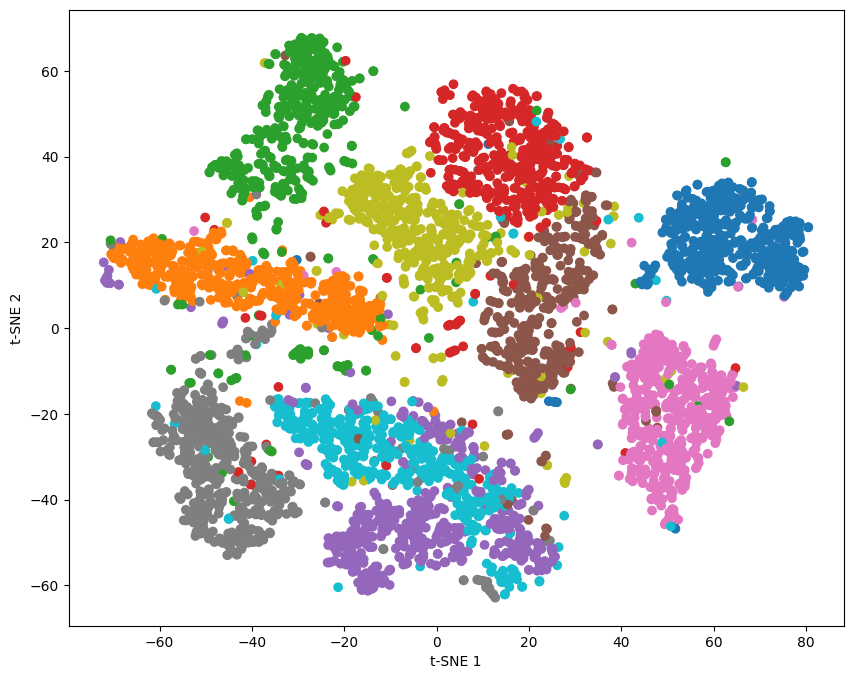

In [ ]:
# Exercises 10. t_SNE 2차원 축소 및 시각화(PCA, LLE, MDS와 비교)

from sklearn.manifold import TSNE, LocallyLinearEmbedding, MDS
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# mnist 데이터셋
mnist = fetch_openml('mnist_784', as_frame=False)
X_sample, y_sample = mnist.data[:5_000], mnist.target[:5_000]

tsne = TSNE(n_components=2, random_state=42)
X_reduced_tsne = tsne.fit_transform(X_sample)

# 산점도 시각화(2차원 축소 했으니까 두 피쳐만)
plt.figure(figsize=(10, 8))
plt.scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1], c=y_sample.astype(int), cmap="tab10")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

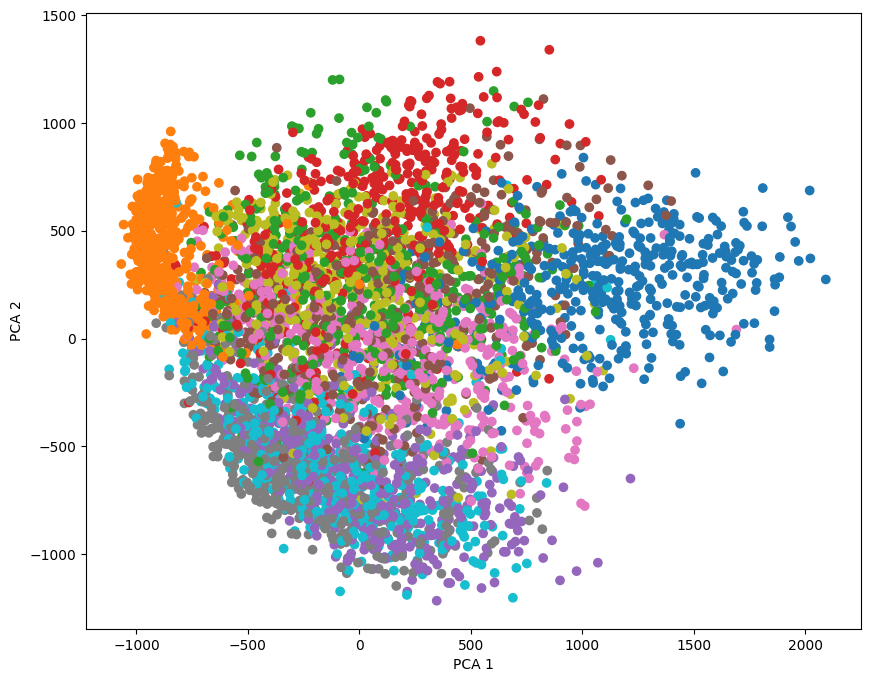

In [15]:
# PCA
pca = PCA(n_components=2, random_state=42)
X_reduced_pca = pca.fit_transform(X_sample)

# 산점도 시각화(2차원 축소 했으니까 두 피쳐만)
plt.figure(figsize=(10, 8))
plt.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=y_sample.astype(int), cmap="tab10")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

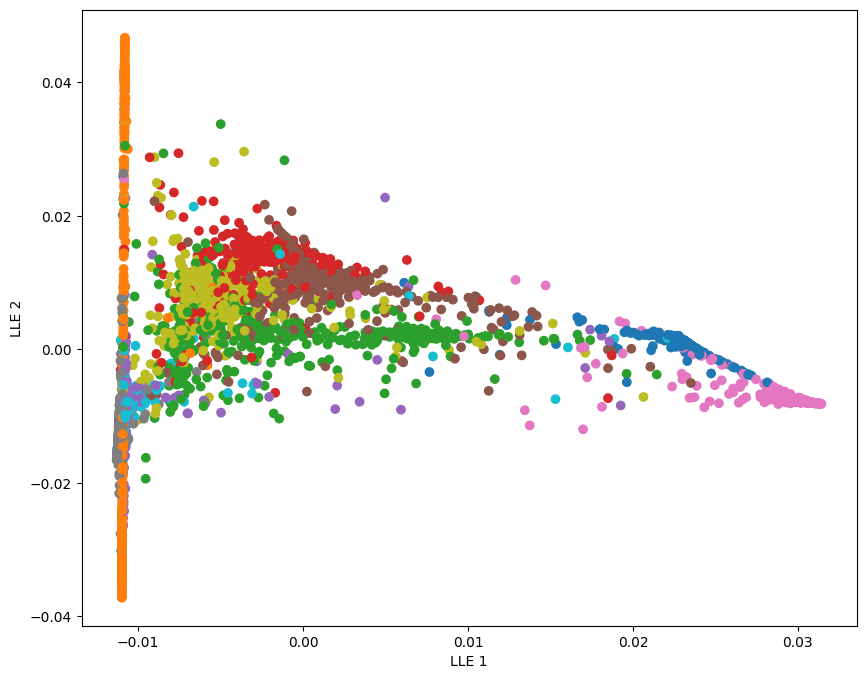

In [ ]:
from sklearn.manifold import LocallyLinearEmbedding
# LLE
lle = LocallyLinearEmbedding(n_components=2, random_state=42)
X_reduced_lle = lle.fit_transform(X_sample)

# 산점도 시각화(2차원 축소 했으니까 두 피쳐만)
plt.figure(figsize=(10, 8))
plt.scatter(X_reduced_lle[:, 0], X_reduced_lle[:, 1], c=y_sample.astype(int), cmap="tab10")
plt.xlabel("LLE 1")
plt.ylabel("LLE 2")
plt.show()

In [ ]:
mds = MDS(n_components=2, random_state=42)
X_reduced_mds = mds.fit_transform(X_sample)

# 산점도 시각화(2차원 축소 했으니까 두 피쳐만)
plt.figure(figsize=(10, 8))
plt.scatter(X_reduced_mds[:, 0], X_reduced_mds[:, 1], c=y_sample.astype(int), cmap="tab10")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")
plt.show()

c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
